In [5]:
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
import numpy as np
import sys
from pathlib import Path
import pandas as pd

In [6]:
root_dir = Path(r"Z:\Bel\Farid\Outputs")
# Find all CSV files recursively
csv_files = list(root_dir.rglob("*.csv"))

if not csv_files:
    print("No CSV files found.")
else:
    dfs = []
    
    for f in csv_files:
        try:
            df = pd.read_csv(f)
            df["source_file"] = str(f)          # optional: keep track of original file
            df["source_folder"] = str(f.parent) # optional
            dfs.append(df)
            print(f"Loaded: {f}")
        except Exception as e:
            print(f"Failed to read {f}: {e}")

    if dfs:
        combined = pd.concat(dfs, ignore_index=True, sort=False)
        
        output_file = root_dir / "all_csvs_concatenated.csv"
        combined.to_csv(output_file, index=False)
        
        print(f"\nSaved concatenated CSV to:\n{output_file}")
        print(f"Total files combined: {len(dfs)}")
        print(f"Combined shape: {combined.shape}")
    else:
        print("No CSV files could be read successfully.")

Loaded: Z:\Bel\Farid\Outputs\03.10.25 flow 6million day 7_img5_valve 1_Merged\03.10.25 flow 6million day 7_img5_valve 1_Merged_analysis_metrics.csv
Loaded: Z:\Bel\Farid\Outputs\03.10.25 flow 6million day 7_img6_valve 2_Merged\03.10.25 flow 6million day 7_img6_valve 2_Merged_analysis_metrics.csv
Loaded: Z:\Bel\Farid\Outputs\03.10.25 flow 6million day 7_img7_valve 4_Merged\03.10.25 flow 6million day 7_img7_valve 4_Merged_analysis_metrics.csv
Loaded: Z:\Bel\Farid\Outputs\03.10.25 flow 6million day 7_img8_valve 5_Merged\03.10.25 flow 6million day 7_img8_valve 5_Merged_analysis_metrics.csv
Loaded: Z:\Bel\Farid\Outputs\03.10.25 flow 6million day 7_img9_valve 8_Merged\03.10.25 flow 6million day 7_img9_valve 8_Merged_analysis_metrics.csv
Loaded: Z:\Bel\Farid\Outputs\03.10.25 flow 8 millions day 10_img5_valve 1_Merged\03.10.25 flow 8 millions day 10_img5_valve 1_Merged_analysis_metrics.csv
Loaded: Z:\Bel\Farid\Outputs\03.10.25 flow 8 millions day 10_img6_valve 2_Merged\03.10.25 flow 8 millions 

In [16]:
combined.columns

Index(['image_name', 'source_file', 'image_index', 'chip_volume_um3',
       'vessel_volume_um3', 'vessel_volume_fraction', 'total_vessel_length_um',
       'vessel_length_per_chip_volume_um_inverse2',
       'sprouts_per_vessel_length_um_inverse',
       'junctions_per_vessel_length_um_inverse', 'skeleton_fractal_dimension',
       'skeleton_lacunarity', 'median_sprout_and_branch_tortuosity',
       'p90_minus_p10_sprout_and_branch_tortuosity',
       'median_sprout_and_branch_median_cs_area_um2',
       'p90_minus_p10_sprout_and_branch_median_cs_area_um2',
       'median_junction_dist_nearest_junction_um',
       'p90_minus_p10_junction_dist_nearest_junction_um',
       'median_sprout_dist_nearest_endpoint_um',
       'p90_minus_p10_sprout_dist_nearest_endpoint_um',
       'total_internal_pore_count',
       'internal_pore_area_fraction_in_filled_vascular_area',
       'median_internal_pore_area_um2', 'p90_minus_p10_internal_pore_area_um2',
       'median_internal_pore_max_inscribed_

In [8]:
combined["experiment"] = combined["image_name"].astype(str).str.contains("flow", case=False, na=False).map({True: "flow", False: "static"})

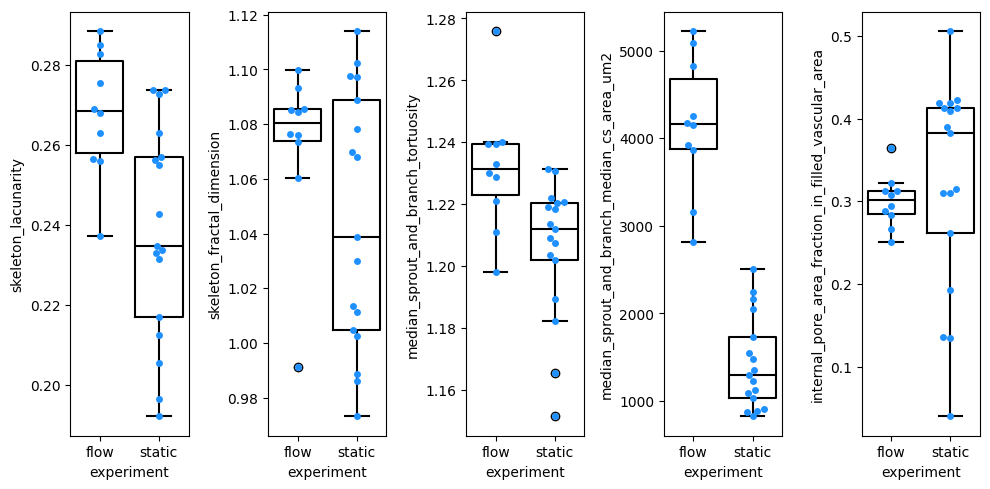

In [26]:
fig, ax = plt.subplots(ncols = 5, figsize=(10,5))
sns.swarmplot(data = combined, x="experiment", y="skeleton_lacunarity", ax=ax[0], zorder=100, color="dodgerblue")
sns.boxplot(data = combined, x="experiment", y="skeleton_lacunarity", ax=ax[0], fill=False, color="#000000")

sns.swarmplot(data = combined, x="experiment", y="skeleton_fractal_dimension", ax=ax[1], zorder=100, color="dodgerblue")
sns.boxplot(data = combined, x="experiment", y="skeleton_fractal_dimension", ax=ax[1], fill=False, color="#000000")

sns.swarmplot(data = combined, x="experiment", y="median_sprout_and_branch_tortuosity", ax=ax[2], zorder=100, color="dodgerblue")
sns.boxplot(data = combined, x="experiment", y="median_sprout_and_branch_tortuosity", ax=ax[2], fill=False, color="#000000")

sns.swarmplot(data = combined, x="experiment", y="median_sprout_and_branch_median_cs_area_um2", ax=ax[3], zorder=100, color="dodgerblue")
sns.boxplot(data = combined, x="experiment", y="median_sprout_and_branch_median_cs_area_um2", ax=ax[3], fill=False, color="#000000")

sns.swarmplot(data = combined, x="experiment", y="internal_pore_area_fraction_in_filled_vascular_area", ax=ax[4], zorder=100, color="dodgerblue")
sns.boxplot(data = combined, x="experiment", y="internal_pore_area_fraction_in_filled_vascular_area", ax=ax[4], fill=False, color="#000000")

plt.tight_layout()

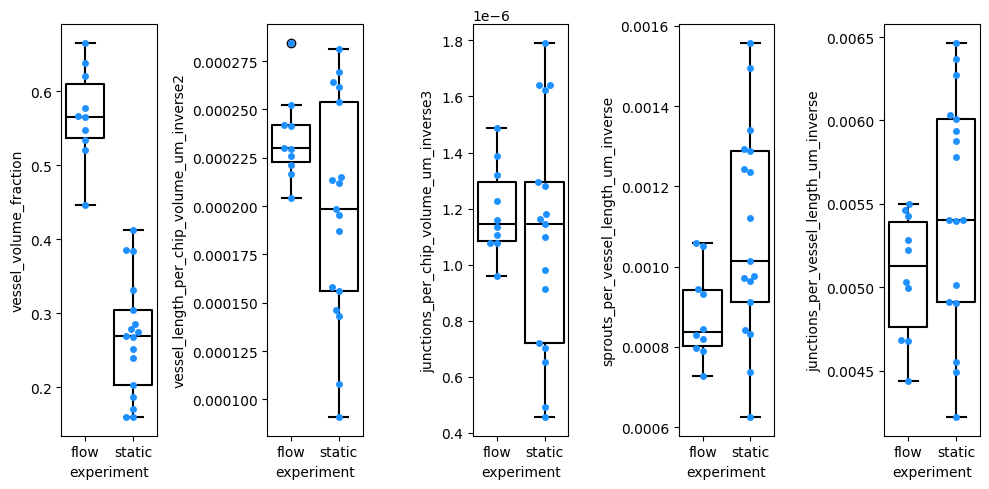

In [29]:
fig, ax = plt.subplots(ncols = 5, figsize=(10,5))
sns.swarmplot(data = combined, x="experiment", y="vessel_volume_fraction", ax=ax[0], zorder=100, color="dodgerblue")
sns.boxplot(data = combined, x="experiment", y="vessel_volume_fraction", ax=ax[0], fill=False, color="#000000")

sns.swarmplot(data = combined, x="experiment", y="vessel_length_per_chip_volume_um_inverse2", ax=ax[1], zorder=100, color="dodgerblue")
sns.boxplot(data = combined, x="experiment", y="vessel_length_per_chip_volume_um_inverse2", ax=ax[1], fill=False, color="#000000")

sns.swarmplot(data = combined, x="experiment", y="junctions_per_chip_volume_um_inverse3", ax=ax[2], zorder=100, color="dodgerblue")
sns.boxplot(data = combined, x="experiment", y="junctions_per_chip_volume_um_inverse3", ax=ax[2], fill=False, color="#000000")

sns.swarmplot(data = combined, x="experiment", y="sprouts_per_vessel_length_um_inverse", ax=ax[3], zorder=100, color="dodgerblue")
sns.boxplot(data = combined, x="experiment", y="sprouts_per_vessel_length_um_inverse", ax=ax[3], fill=False, color="#000000")

sns.swarmplot(data = combined, x="experiment", y="junctions_per_vessel_length_um_inverse", ax=ax[4], zorder=100, color="dodgerblue")
sns.boxplot(data = combined, x="experiment", y="junctions_per_vessel_length_um_inverse", ax=ax[4], fill=False, color="#000000")

plt.tight_layout()